# Analyse de Réseau et Co-occurrence des Tags de Gameplay

## Objectif
Après avoir structuré nos tags dans une taxonomie propre (voir `2_Gameplay_Tag_Taxonomy.ipynb`), nous allons analyser les corrélations entre les différentes dimensions.

Cette étape est cruciale pour :
1. **Identifier des patterns de design** : Groupements naturels de mécaniques et genres.
2. **Détecter des communautés** : Identifier des sous-groupes de jeux fortement liés.
3. **Analyser la topologie** : Repérer les tags "hubs" (centraux) et les "ponts" (betweenness).
4. **Explorer la dimension temporelle** : Voir comment ces associations évoluent dans le temps.
5. **Approche Multidimensionnelle** : Croiser Genre, Mécaniques, Thèmes et Mood.


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
plt.rcParams.update({
    'figure.facecolor': 'white', 
    'axes.facecolor': 'white', 
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'figure.autolayout': True
})
def save_plot(name):
    if not os.path.exists('figures'): os.makedirs('figures')
    plt.gcf().canvas.draw()
    plt.savefig(f'figures/3_{name}.png', bbox_inches='tight', facecolor='white', dpi=300)
import os
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white'})
def save_plot(name):
    if not os.path.exists('figures'): os.makedirs('figures')
    plt.savefig(f'figures/3_{name}.png', bbox_inches='tight', facecolor='white')
import networkx as nx
import numpy as np
from networkx.algorithms import community

# Chargement de la base structurée
df = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')

# Conversion de la date
# Format yymmdd (ex: 231025)
df['game_release_date'] = pd.to_datetime(df['game_release_date'].astype(str).str.zfill(6), format='%y%m%d', errors='coerce')
df['year'] = df['game_release_date'].dt.year

print(f"Base chargée : {df.shape[0]} jeux.")
df.head()


Base chargée : 100384 jeux.


,game_id,game_name,game_release_date,Aesthetics,Genre,Mechanics,Mood,Perspective,Players,Setting,Theme,year
0,1,"Cook, Serve, Delicious! 3?!",2020-10-14,2D,"Management, Casual, Strategy, Simulation, Action",NaN,"Difficult, Funny",NaN,"Co-op, Local Co-Op, Multiplayer, Local Multipl...",NaN,Family Friendly,2020.0
1,2,Hellish Quart,2021-02-16,3D,"Fighting, 3D Fighter, Action","Character Customization, Physics",Cinematic,Third Person,"PvE, PvP, Local Multiplayer",NaN,"Swordplay, Historical, Medieval, Combat",2021.0
2,3,The ScreaMaze,2019-01-10,NaN,Puzzle,NaN,NaN,NaN,Singleplayer,NaN,NaN,2019.0
3,4,Clam Man,2019-05-23,NaN,"Adventure, Point & Click",NaN,Funny,NaN,NaN,NaN,NaN,2019.0
4,5,Fist Of Heaven & Hell,2019-06-28,NaN,"Action, Adventure",NaN,NaN,NaN,NaN,NaN,NaN,2019.0


## 1. Matrice de Co-occurrence et Lift (Genre vs Mécaniques)

Nous calculons la fréquence d'apparition conjointe des Genres et Mécaniques, puis nous normalisons avec le **Lift** pour identifier les liens significatifs (au-delà du hasard).


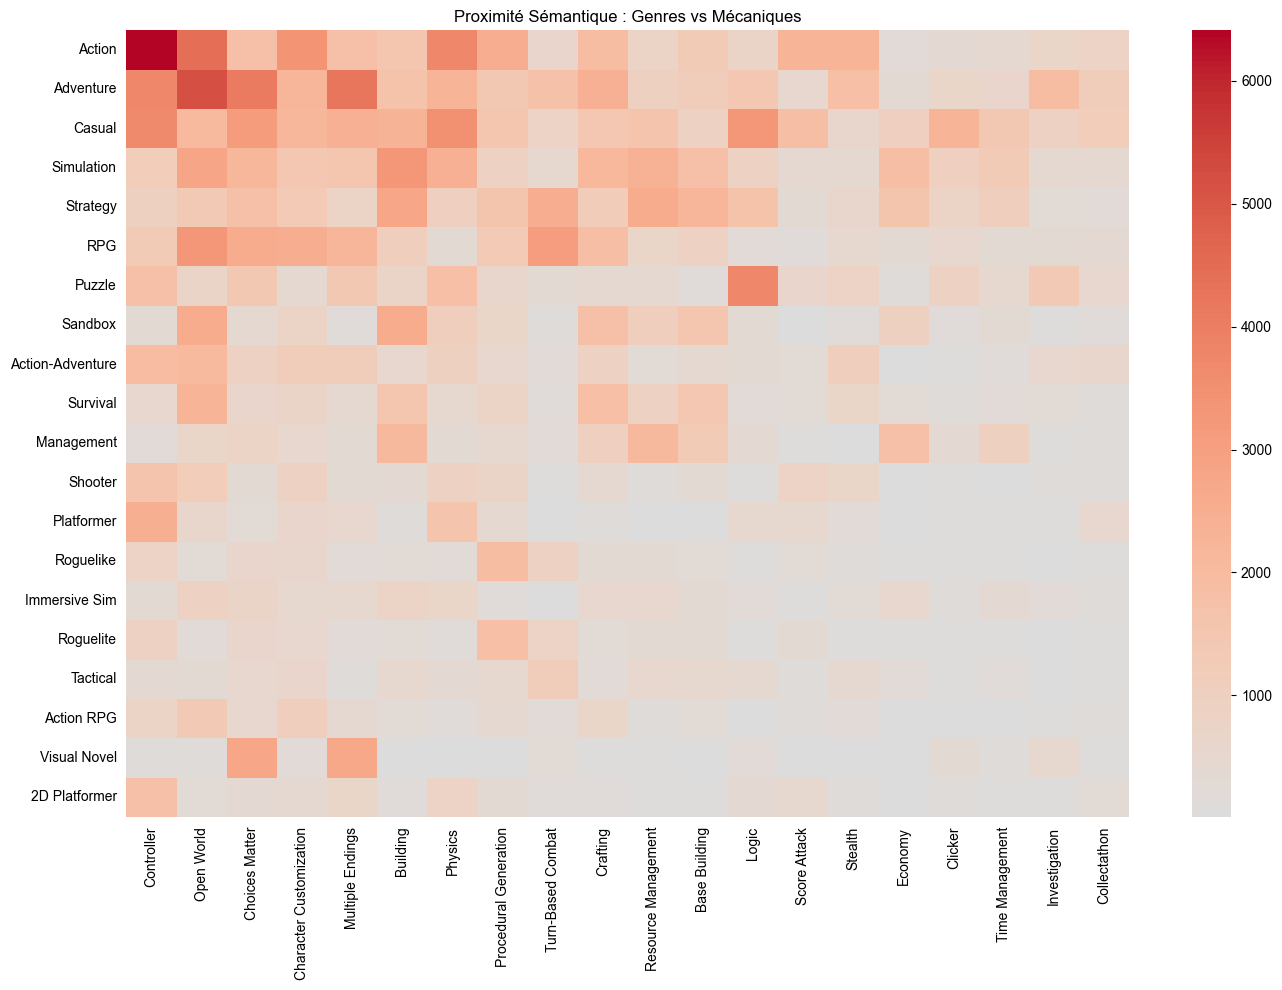

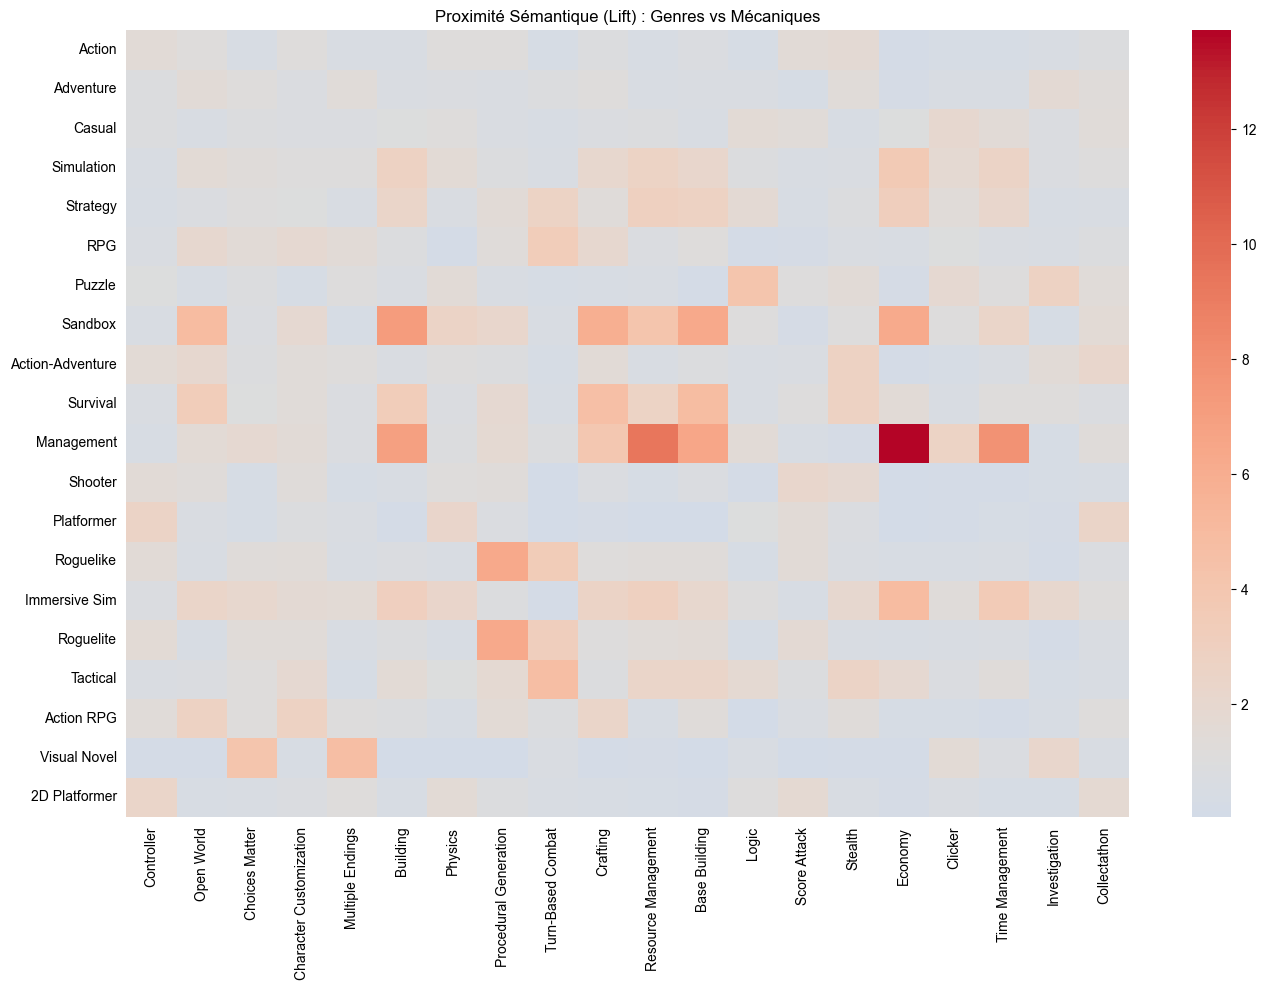

In [31]:
def get_cooccurrence_matrix(df, col1, col2):
    # Extraction des listes de tags
    s1 = df[col1].str.split(', ').fillna('').tolist()
    s2 = df[col2].str.split(', ').fillna('').tolist()
    
    # Liste de tous les tags uniques pour chaque colonne
    tags1 = sorted(list(set([t for sub in s1 for t in sub if t])))
    tags2 = sorted(list(set([t for sub in s2 for t in sub if t])))
    
    matrix = pd.DataFrame(0, index=tags1, columns=tags2)
    
    for i in range(len(s1)):
        t1_list = [t for t in s1[i] if t]
        t2_list = [t for t in s2[i] if t]
        for t1 in t1_list:
            for t2 in t2_list:
                matrix.loc[t1, t2] += 1
    return matrix

def get_lift_matrix(df, cooc_matrix, col1, col2):
    N = len(df)
    c1_counts = df[col1].str.split(', ').explode().value_counts()
    c2_counts = df[col2].str.split(', ').explode().value_counts()

    lift_matrix = cooc_matrix.copy().astype(float)
    for i in lift_matrix.index:
        for j in lift_matrix.columns:
            if i in c1_counts and j in c2_counts:
                expected = (c1_counts[i] * c2_counts[j]) / N
                if expected > 0:
                    lift_matrix.loc[i, j] = cooc_matrix.loc[i, j] / expected
                else:
                    lift_matrix.loc[i, j] = 0
            else:
                lift_matrix.loc[i, j] = 0
    return lift_matrix

# Calculs
cooc_gm = get_cooccurrence_matrix(df, 'Genre', 'Mechanics')
lift_gm = get_lift_matrix(df, cooc_gm, 'Genre', 'Mechanics')

# Sélection des Tops pour visualisation
top_genres = cooc_gm.sum(axis=1).sort_values(ascending=False).head(20).index
top_mechanics = cooc_gm.sum(axis=0).sort_values(ascending=False).head(20).index

# Visualisation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cooc_gm.loc[top_genres, top_mechanics], annot=False, cmap="coolwarm", center=1)
plt.title("Proximité Sémantique : Genres vs Mécaniques")
save_plot('plot')
plt.show()

# Visualisation Heatmap Lift
plt.figure(figsize=(14, 10))
sns.heatmap(lift_gm.loc[top_genres, top_mechanics], annot=False, cmap="coolwarm", center=1)
plt.title("Proximité Sémantique (Lift) : Genres vs Mécaniques")
save_plot('plot')
plt.show()


*La matrice de corrélation brute montre les associations les plus fréquentes, mais elle est biaisée par la popularité des tags. Par exemple, un genre très populaire comme "Action" apparaîtra souvent avec de nombreuses mécaniques simplement parce qu'il est présent dans beaucoup de jeux. C'est pourquoi nous allons normaliser cette matrice pour mieux comprendre les associations significatives.*

*Avec la matrice amélioré par le lift, on remarque que certaines associations ont un Lift très élevé, indiquant qu'elles sont beaucoup plus fréquentes que ce à quoi on pourrait s'attendre par hasard. Le genre "Management" par exemple, est très fortement associés à certaines mécaniques telles que l'économie, le management de ressources ou le management de temps. Ces associations sont des patterns de design forts qui semble si forte qu'elles peuvent être perçues comme des "règles" de design. Par exemple, un jeu de management qui n'inclut pas de mécaniques d'économie ou de gestion de ressources serait perçu comme manquant d'éléments essentiels à son genre.*

## 2. Analyse de Réseau Avancée : Communautés et Centralité

Nous construisons un graphe basé sur le Lift (> 2.5) pour visualiser la structure du gameplay.
Nous ajoutons :
- **Détection de Communautés** : Pour colorer les nœuds par groupe d'appartenance.
- **Centralité** : Pour identifier les tags les plus influents.


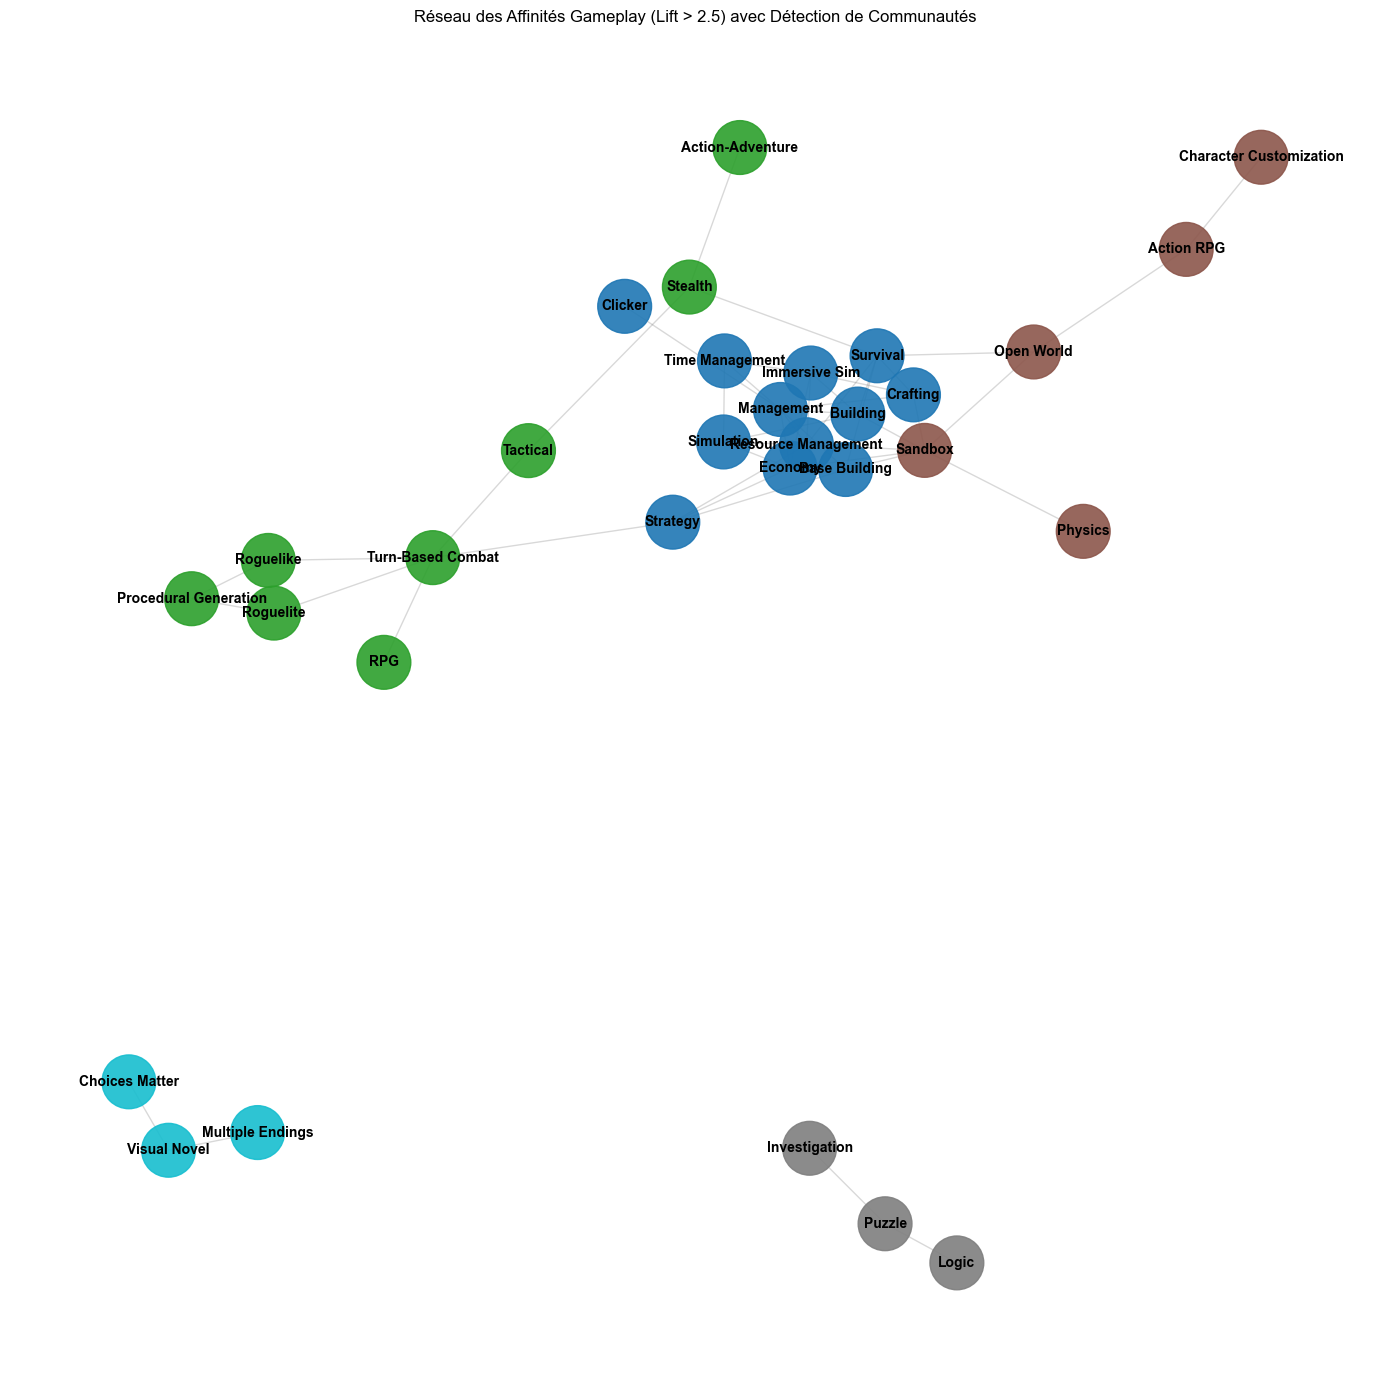

--- Top 5 Tags par Centralité de Degré (Hubs) ---
Sandbox                0.233333
Management             0.233333
Resource Management    0.200000
Survival               0.200000
Economy                0.166667
dtype: float64

--- Top 5 Tags par Centralité d'Intermédiarité (Ponts) ---
Turn-Based Combat      0.207423
Strategy               0.187413
Survival               0.155080
Sandbox                0.131845
Resource Management    0.111336
dtype: float64


In [32]:
G = nx.Graph()
threshold = 2.5

# Construction du graphe
for g in top_genres:
    for m in top_mechanics:
        weight = lift_gm.loc[g, m]
        if weight > threshold:
            G.add_edge(g, m, weight=weight, type='relation')
            G.nodes[g]['type'] = 'Genre'
            G.nodes[m]['type'] = 'Mechanic'

# Détection de communautés (Louvain ou Greedy Modularity)
communities = community.greedy_modularity_communities(G)
# Création d'une map node -> community_id
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

# Couleurs des nœuds selon la communauté
node_colors = [community_map.get(node, 0) for node in G.nodes()]

plt.figure(figsize=(14, 14), facecolor='white')
pos = nx.spring_layout(G, k=0.4, seed=42)

# Dessin
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.tab10, node_size=1500, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='black', font_family='sans-serif')

plt.title(f"Réseau des Affinités Gameplay (Lift > {threshold}) avec Détection de Communautés")
plt.axis('off')
save_plot('plot')
plt.show()

# --- Analyse de Centralité ---
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)

print("--- Top 5 Tags par Centralité de Degré (Hubs) ---")
print(pd.Series(degree_cent).sort_values(ascending=False).head(5))

print("\n--- Top 5 Tags par Centralité d'Intermédiarité (Ponts) ---")
print(pd.Series(betweenness_cent).sort_values(ascending=False).head(5))


*Avec un lift de 2.5, certains groupes n'intéragissent pas du tout entre eux, ainsi se forment 3 graphes connexes :*
- *un relatif aux jeux à puzzle*
- *un autre relatif au visual novel*
- *un dernier qui regroupe lui-même plusieurs sous groupes tel que les roguelike, les action rpg, ou encore les jeux de simulation*

*L'analyse de centralité nous révèle les "Hubs" (tags connectés à beaucoup d'autres, comme 'Sandbox' ou 'Management') et les "Ponts" (tags qui lient des communautés différentes, permettant l'hybridation, comme 'Turn-Based Combat' ou 'Strategy').*


## 3. Analyse Multidimensionnelle

Analysons les couples Genre-Thèmes et Mécaniques-Mood.


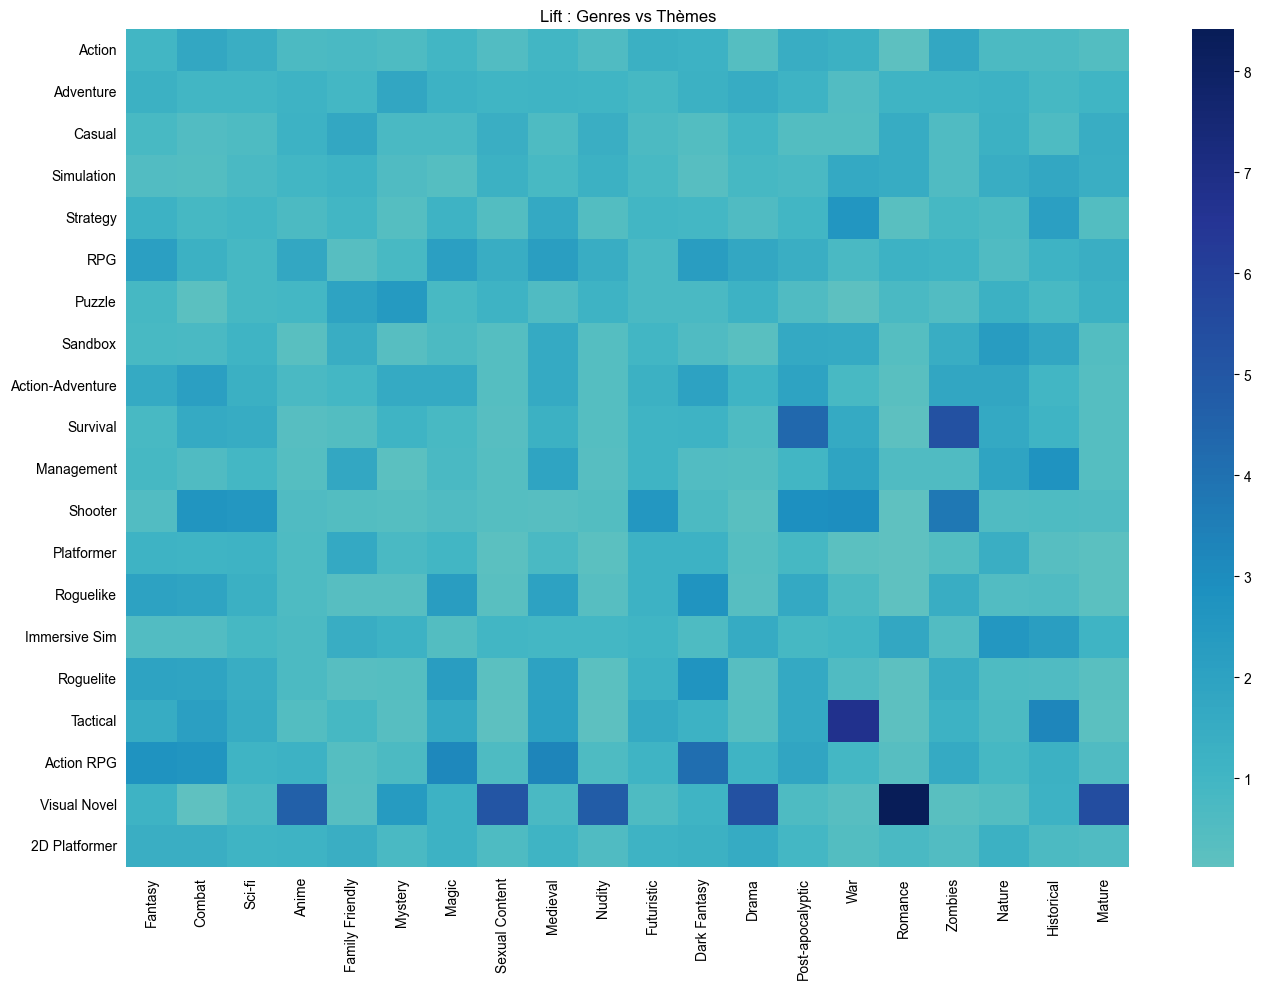

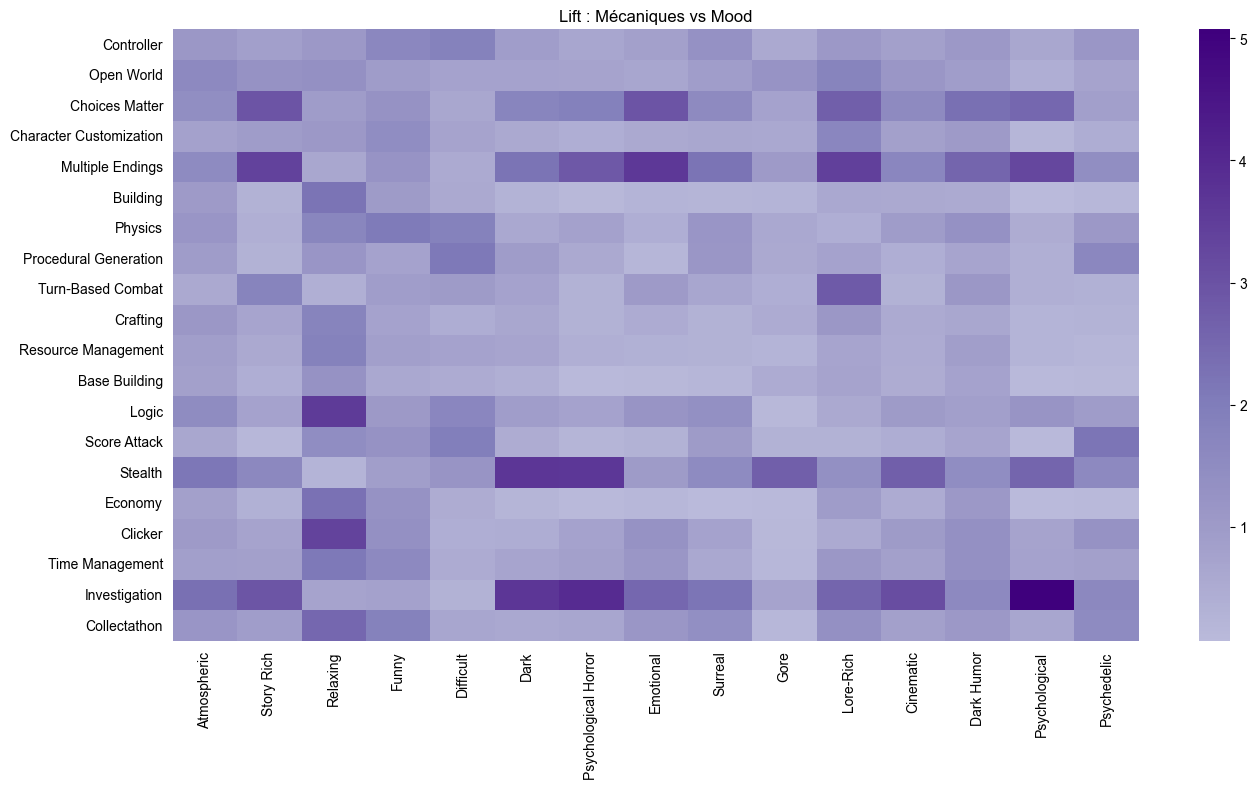

In [33]:
# Genre vs Theme
cooc_gt = get_cooccurrence_matrix(df, 'Genre', 'Theme')
lift_gt = get_lift_matrix(df, cooc_gt, 'Genre', 'Theme')

top_themes = cooc_gt.sum(axis=0).sort_values(ascending=False).head(20).index

plt.figure(figsize=(14, 10))
sns.heatmap(lift_gt.loc[top_genres, top_themes], annot=False, cmap="YlGnBu", center=1)
plt.title("Lift : Genres vs Thèmes")
save_plot('plot')
plt.show()

# Mechanics vs Mood
cooc_mm = get_cooccurrence_matrix(df, 'Mechanics', 'Mood')
lift_mm = get_lift_matrix(df, cooc_mm, 'Mechanics', 'Mood')

top_moods = cooc_mm.sum(axis=0).sort_values(ascending=False).head(15).index

plt.figure(figsize=(14, 8))
sns.heatmap(lift_mm.loc[top_mechanics, top_moods], annot=False, cmap="Purples", center=1)
plt.title("Lift : Mécaniques vs Mood")
save_plot('plot')
plt.show()


## 4. Analyse Temporelle : Évolution des Tendances

Comment la popularité des principaux genres et mécaniques a-t-elle évolué au fil des années ?


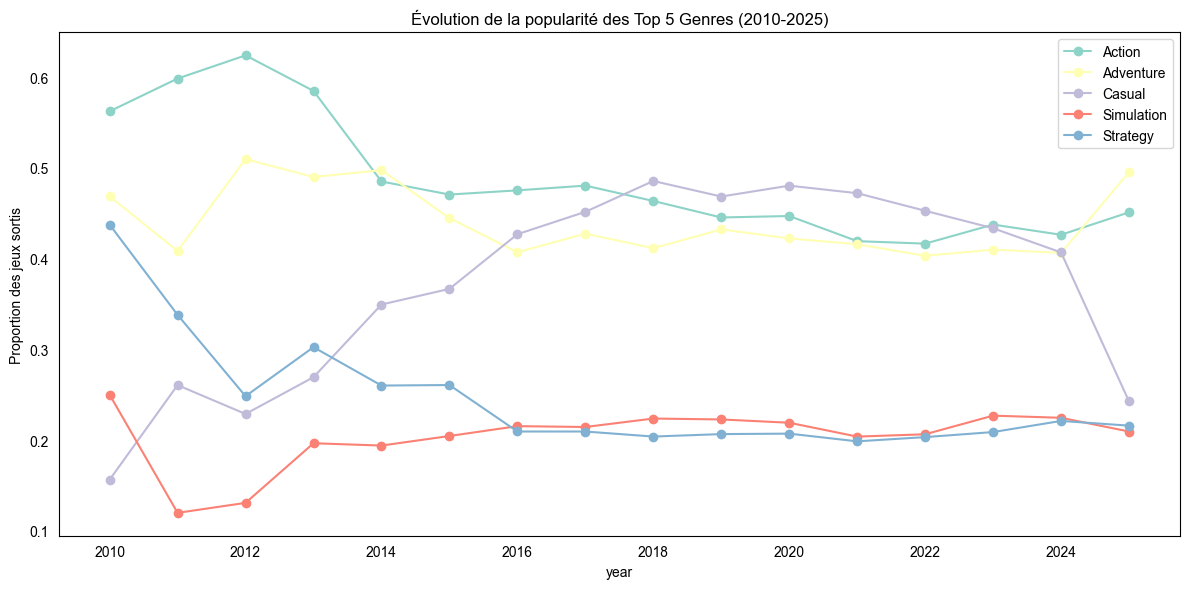

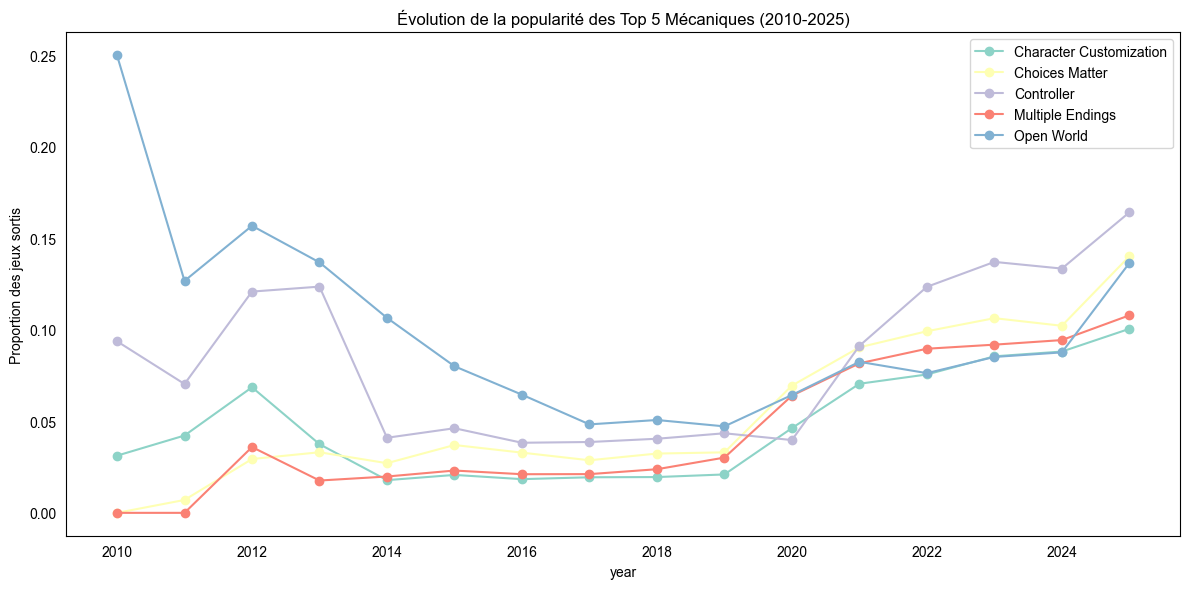

In [34]:
# Filtrage sur les années pertinentes
df_time = df[(df['year'] >= 2010) & (df['year'] <= 2025)].copy()

# Fonction pour compter les tags par année
def count_tags_by_year(df, column, top_tags):
    counts = df.groupby('year')[column].apply(lambda x: pd.Series([t for sub in x.str.split(', ').fillna('') for t in sub if t in top_tags]).value_counts()).unstack().fillna(0)
    # Normalisation par le nombre total de jeux par année (pour avoir une proportion)
    games_per_year = df.groupby('year').size()
    return counts.div(games_per_year, axis=0)

# Evolution des Top 5 Genres
top_5_genres = top_genres[:5]
genre_evol = count_tags_by_year(df_time, 'Genre', top_5_genres)

plt.figure(figsize=(12, 6))
genre_evol.plot(kind='line', marker='o', ax=plt.gca())
plt.title("Évolution de la popularité des Top 5 Genres (2010-2025)")
plt.ylabel("Proportion des jeux sortis")
plt.grid(True, linestyle='--', alpha=0.5)
save_plot('plot')
plt.show()

# Evolution des Top 5 Mécaniques
top_5_mech = top_mechanics[:5]
mech_evol = count_tags_by_year(df_time, 'Mechanics', top_5_mech)

plt.figure(figsize=(12, 6))
mech_evol.plot(kind='line', marker='o', ax=plt.gca())
plt.title("Évolution de la popularité des Top 5 Mécaniques (2010-2025)")
plt.ylabel("Proportion des jeux sortis")
plt.grid(True, linestyle='--', alpha=0.5)
save_plot('plot')
plt.show()


## 5. Analyse des Motifs Fréquents (FP-Growth)

Recherche de règles d'association complexes (ex: {A, B} -> {C}).


Top 15 Règles d'Association (par Lift) :
                                    antecedents  \
318   frozenset({Turn-Based Tactics, Strategy})   
323            frozenset({Turn-Based Strategy})   
446               frozenset({Action Roguelike})   
443              frozenset({Action, Roguelike})   
453               frozenset({Action Roguelike})   
448              frozenset({Roguelite, Action})   
322             frozenset({Turn-Based Tactics})   
319  frozenset({Turn-Based Strategy, Strategy})   
312             frozenset({Turn-Based Tactics})   
313            frozenset({Turn-Based Strategy})   
315             frozenset({Turn-Based Tactics})   
314              frozenset({Turn-Based Combat})   
200              frozenset({Action, Roguelike})   
201                      frozenset({Roguelite})   
308              frozenset({Turn-Based Combat})   

                                    consequents   support  confidence  \
318            frozenset({Turn-Based Strategy})  0.024695    0.739338

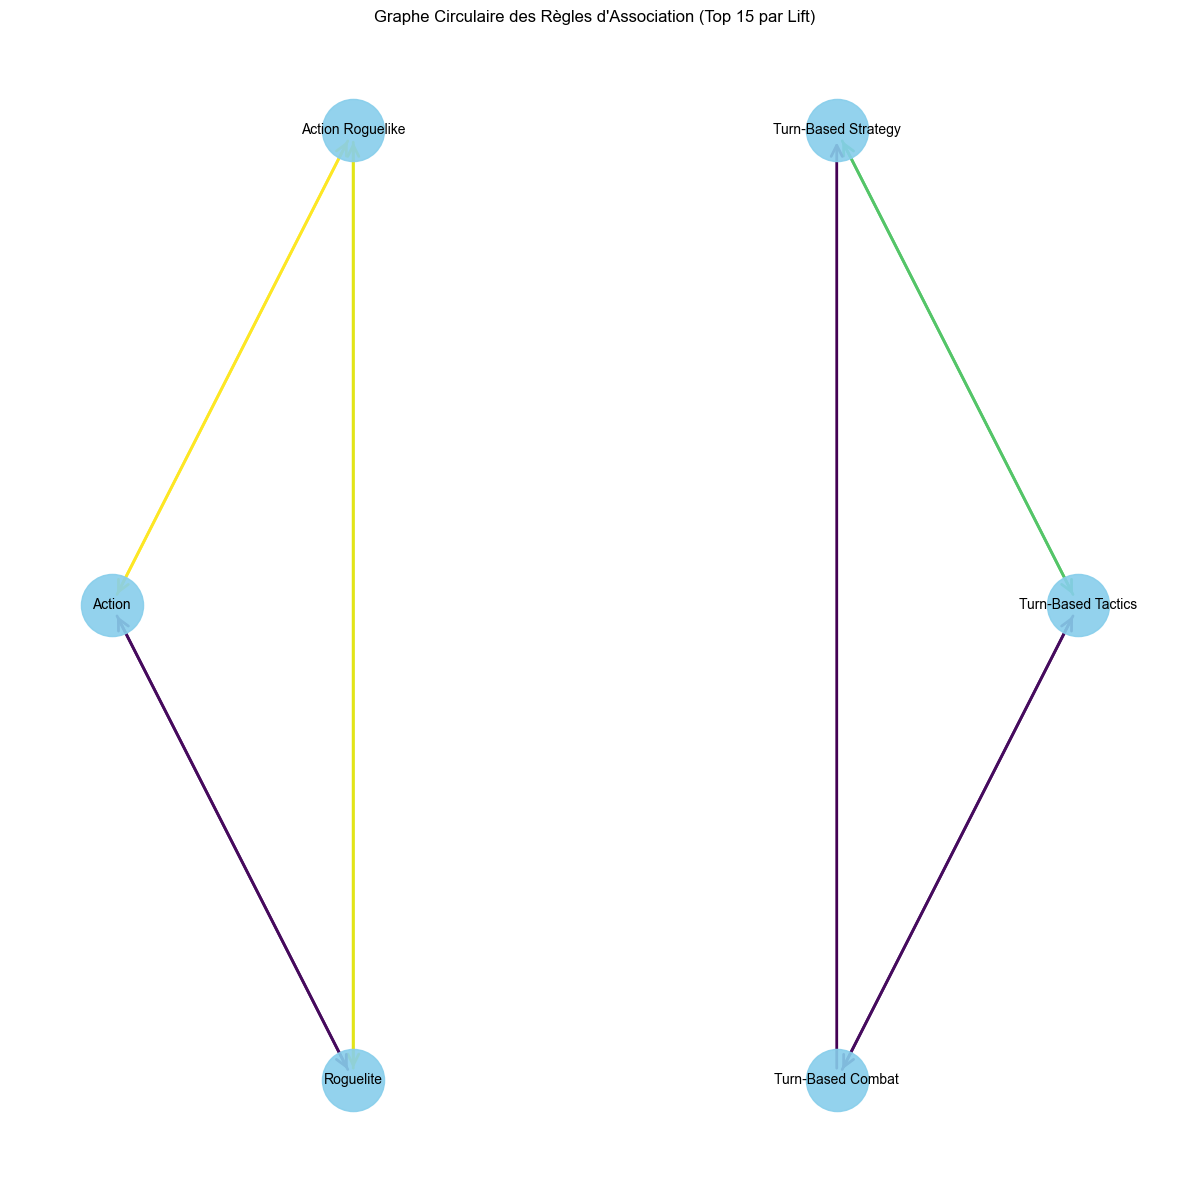

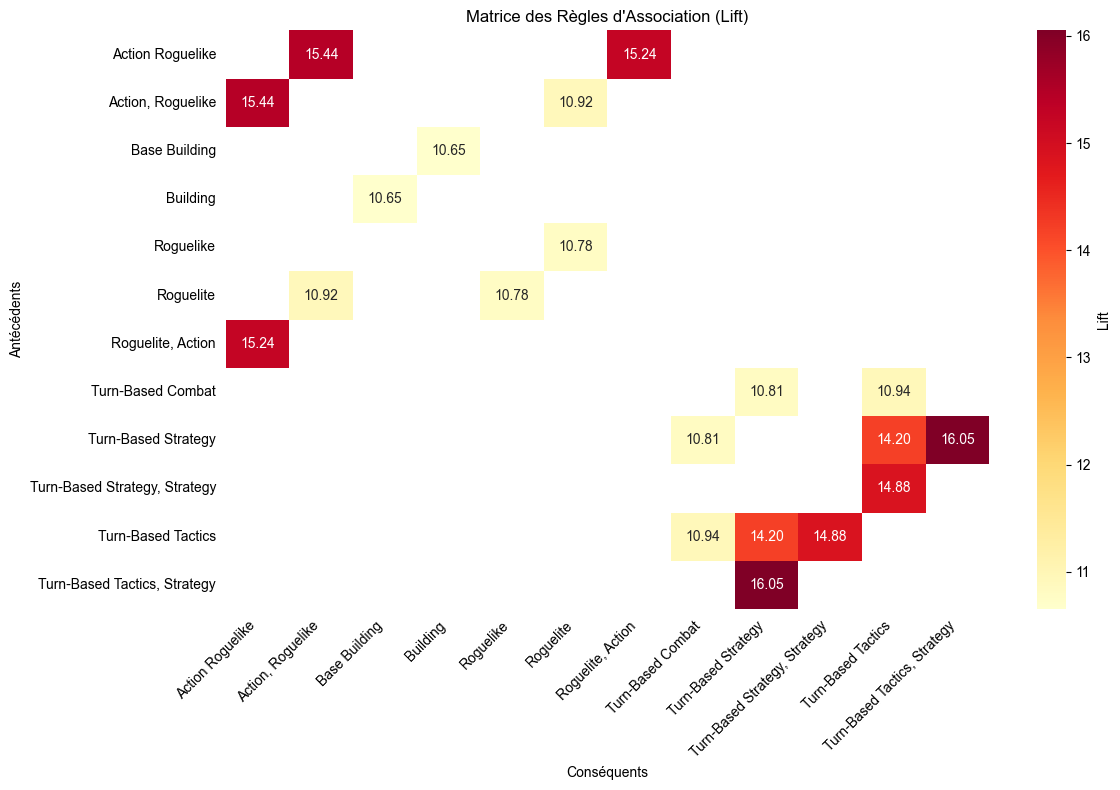

In [35]:
# Tentative d'import de mlxtend pour FP-Growth
try:
    from mlxtend.frequent_patterns import fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    import numpy as np

    # Préparation : Liste de listes de tags
    # On combine Genre et Mechanics
    transactions = []
    for i in df.index:
        row_tags = []
        if pd.notna(df.loc[i, 'Genre']):
            row_tags.extend(df.loc[i, 'Genre'].split(', '))
        if pd.notna(df.loc[i, 'Mechanics']):
            row_tags.extend(df.loc[i, 'Mechanics'].split(', '))
        # Nettoyage
        row_tags = [t for t in row_tags if t and t != 'nan']
        transactions.append(row_tags)

    # Encodage
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_trans = pd.DataFrame(te_ary, columns=te.columns_)

    # FP-Growth
    # min_support = 0.02 (2% des jeux) pour ne pas avoir trop de bruit
    frequent_itemsets = fpgrowth(df_trans, min_support=0.02, use_colnames=True)

    # Règles d'association
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

    # Tri par Lift
    top_rules = rules.sort_values(by='lift', ascending=False).head(15)

    print("Top 15 Règles d'Association (par Lift) :")
    print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

    # --- Visualisation 1 : Graphe Circulaire des Règles ---
    plt.figure(figsize=(12, 12))
    G_rules = nx.DiGraph()

    # On ajoute les règles au graphe
    for idx, row in top_rules.iterrows():
        ant = list(row['antecedents'])[0] # On prend le premier élément pour simplifier l'affichage
        con = list(row['consequents'])[0]
        weight = row['lift']
        G_rules.add_edge(ant, con, weight=weight)

    pos = nx.circular_layout(G_rules)

    # Dessin des nœuds
    nx.draw_networkx_nodes(G_rules, pos, node_size=2000, node_color='skyblue', alpha=0.9)

    # Dessin des arêtes avec couleur selon le poids (Lift)
    edges = G_rules.edges()
    weights = [G_rules[u][v]['weight'] for u,v in edges]

    nx.draw_networkx_edges(G_rules, pos, width=2, edge_color=weights, edge_cmap=plt.cm.viridis,
                           arrowstyle='->', arrowsize=20)

    # Labels
    nx.draw_networkx_labels(G_rules, pos, font_size=10, font_family='sans-serif')

    plt.title("Graphe Circulaire des Règles d'Association (Top 15 par Lift)")
    plt.axis('off')
    plt.show()

    # --- Visualisation 2 : Matrice de Confusion des Règles ---
    # On crée une matrice où x=antecedents, y=consequents, value=lift
    # Pour simplifier, on convertit les frozensets en chaînes
    rules['ant_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['con_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    # On filtre pour garder les règles les plus significatives pour la matrice (Top 20)
    top_rules_matrix = rules.sort_values(by='lift', ascending=False).head(20)

    pivot_table = top_rules_matrix.pivot(index='ant_str', columns='con_str', values='lift')

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Lift'})
    plt.title("Matrice des Règles d'Association (Lift)")
    plt.xlabel("Conséquents")
    plt.ylabel("Antécédents")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("La librairie 'mlxtend' n'est pas installée. Veuillez l'installer avec : pip install mlxtend")


*Dans cette nouvelle base de donnée réarrangé, et suite au lift, on obtient des règles d'association forte très différentes de celle obtenue dans notre première analyse.*
*Ces règles d'association mettent en lumière :*
  - *la dominance de certains sous genres dans leur genre d'origine, par exemple les Base Building dans les jeux de construction.*
  - *que certains tags ne sont en réalité que la simple association d'autres tags tel que les Action Roguelike qui sont concrétement l'association d'Action et Roguelike.*
  - *que certains tags sont des "tags de niche" qui n'ont pas de règles d'association forte, mais qui sont pourtant très cohérents. Par exemple, les jeux de puzzle sont très fortement associés à des mécaniques de réflexion et de logique, mais ces mécaniques ne sont pas associées à d'autres genres, ce qui fait que les règles d'association ne sont pas assez fortes pour être mises en avant.*

## Conclusion

Cette analyse approfondie des co-occurrences et des réseaux nous a permis de dépasser les simples fréquences pour comprendre la structure fondamentale du gameplay sur Steam.

**Points clés retenus :**

1.  **La puissance du Lift** : En normalisant par la popularité, nous avons filtré le bruit causé par les tags omniprésents (comme "Action") pour révéler des **règles de design** strictes. Par exemple, l'association quasi-systématique entre *Management* et *Economy/Resource Management* montre que certains genres ne peuvent exister sans leurs mécaniques constitutives.

2.  **Topologie du Réseau** : Le graphe de gameplay n'est pas un tout unique et connecté. Avec un seuil de Lift significatif (2.5), nous observons **trois écosystèmes distincts** qui n'interagissent pas :
    *   Les **Puzzles**, isolés dans leurs mécaniques de logique.
    *   Les **Visual Novels**, formant une bulle narrative à part.
    *   Un **Grand Continent** regroupant la majorité des genres (Roguelike, RPG, Simulation) interconnectés par des tags "ponts" comme *Strategy* ou *Turn-Based Combat*.

3.  **Règles d'Association et Niches** : L'algorithme FP-Growth a mis en lumière la hiérarchie des tags. Certains tags agissent comme des "parents" dominants (ex: *Base Building* dans *Construction*), tandis que d'autres, comme *Action Roguelike*, apparaissent comme de pures compositions sémantiques. Paradoxalement, les genres les plus cohérents (comme les Puzzles) génèrent parfois moins de règles d'association globales car leurs mécaniques sont exclusives et ne se mélangent pas aux autres genres ("tags de niche").

Ces observations confirment que la classification par tags n'est pas seulement une liste de mots-clés, mais une structure complexe avec des hubs, des isolats et des règles de composition strictes. Cela valide la pertinence de notre taxonomie avant de passer à l'étape suivante : le **Clustering Non-Supervisé**, où nous laisserons les algorithmes redécouvrir ces groupes sans a priori.
